In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
df = pd.read_csv('games.csv', encoding="Latin1")
print(f"Dataset cargado: {df.shape}")

Dataset cargado: (122611, 39)


In [ ]:
# Realizar una copia del DataFrame original para evitar modificarlo directamente
df_copia = df.copy()


# Eliminar columnas innecesarias
df_copia = df_copia.drop(columns=['Movies'])
df_copia = df_copia.drop(columns=['Screenshots'])
df_copia = df_copia.drop(columns=['Release date'])
df_copia = df_copia.drop(columns=['Metacritic url'])
df_copia = df_copia.drop(columns=['Support email'])
df_copia = df_copia.drop(columns=['Support url'])
df_copia = df_copia.drop(columns=['Notes'])
df_copia = df_copia.drop(columns=['Publishers'])
df_copia = df_copia.drop(columns=['DiscountDLC count'])
df_copia = df_copia.drop(columns=['About the game'])
df_copia = df_copia.drop(columns=['Reviews'])
df_copia = df_copia.drop(columns=['Header image'])
df_copia = df_copia.drop(columns=['Website'])
df_copia = df_copia.drop(columns=['Recommendations'])
df_copia = df_copia.drop(columns=['Score rank'])
df_copia = df_copia.drop(columns=['Full audio languages'])
df_copia = df_copia.drop(columns=['Average playtime two weeks'])
df_copia = df_copia.drop(columns=['Median playtime two weeks'])


df_copia = df_copia.rename(columns={
    'Name': 'Release',
    'AppID': 'Name',
    'Estimated owners': 'Owners', 
    'Supported languages': 'Languages',
    'Average playtime forever': 'Average playtime',
    'Median playtime forever': 'Median playtime',
})

print(f"Dataset cargado: {df_copia.shape}")


Dataset cargado: (122611, 21)


In [4]:
df_copia.head()

,Name,Release,Owners,Peak CCU,Required age,Price,Languages,Windows,Mac,Linux,...,User score,Positive,Negative,Achievements,Average playtime,Median playtime,Developers,Categories,Genres,Tags
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0,0,0.00,0,[],True,False,False,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,0,5.24,65,['English'],True,False,False,...,0,252,3,0,8,8,minori,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute"
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0,0,4.99,0,"['English', 'French', 'German', 'Russian']",True,True,False,...,0,21,3,0,0,0,Somer Games,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec..."
3292190,ë²íë² íë¼ë ¸ì´ì - Vtuber Paranoia,"Oct 31, 2024",1,0,8.99,0,['Korean'],True,False,False,...,0,0,0,19,0,0,ì ì§ê²ìì¦,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN
3631080,Maze Quest VR,"Apr 24, 2025",0,0,4.99,0,['English'],True,False,False,...,0,0,0,0,0,0,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN


In [5]:
df_copia.columns

Index(['Name', 'Release', 'Owners', 'Peak CCU', 'Required age', 'Price',
       'Languages', 'Windows', 'Mac', 'Linux', 'Metacritic score',
       'User score', 'Positive', 'Negative', 'Achievements',
       'Average playtime', 'Median playtime', 'Developers', 'Categories',
       'Genres', 'Tags'],
      dtype='str')

In [6]:
df_copia.describe()

,Owners,Peak CCU,Required age,Price,Metacritic score,User score,Positive,Negative,Achievements,Average playtime,Median playtime
count,1.226110e+05,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,1.226110e+05
mean,5.459332e+01,0.167611,4.765091,18.353663,2.564941,0.024549,1.044986e+03,1.691974e+02,18.087015,2.080232e+02,1.735705e+02
std,3.729452e+03,1.653591,12.531030,28.858970,13.660559,1.394901,2.809173e+04,5.374645e+03,141.493879,1.121768e+04,1.120254e+04
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000,2.240000,0.000000,0.000000,0.000000,5.000000e+00,1.000000e+00,2.000000,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000,5.240000,40.000000,0.000000,0.000000,3.700000e+01,1.000000e+01,19.000000,0.000000e+00,0.000000e+00
max,1.013936e+06,21.000000,999.980000,100.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,9821.000000,3.429544e+06,3.429544e+06


In [7]:
df_copia[df_copia['Name'] == 'PAYDAY 3']

,Name,Release,Owners,Peak CCU,Required age,Price,Languages,Windows,Mac,Linux,...,User score,Positive,Negative,Achievements,Average playtime,Median playtime,Developers,Categories,Genres,Tags
1272080,PAYDAY 3,"Sep 21, 2023",644,17,14.99,50,"['English', 'French', 'Italian', 'German', 'Sp...",True,False,False,...,0,25497,33195,22,1421,721,Starbreeze Studios,"Single-player,Multi-player,Co-op,Online Co-op,...","Action,Adventure,RPG","Heist,Co-op,Crime,Action,Multiplayer,FPS,Shoot..."


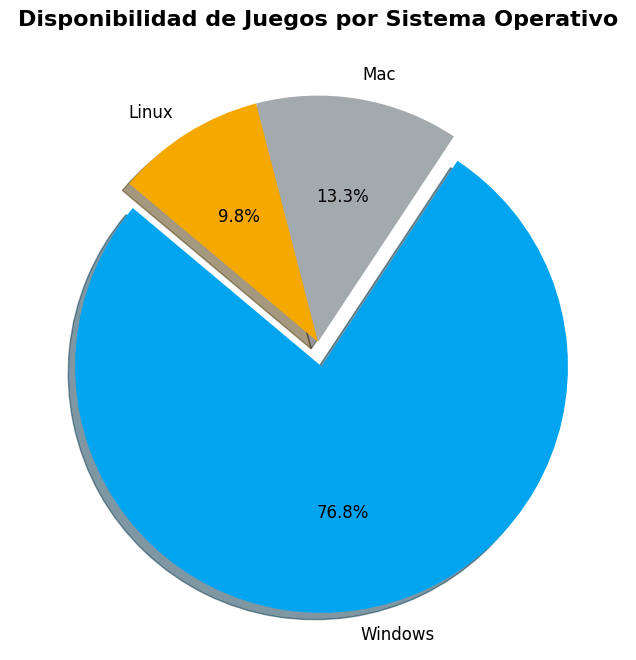

In [9]:
# 1. Calcular el total de juegos por plataforma (sumar los True)
total_windows = df_copia['Windows'].sum()
total_mac = df_copia['Mac'].sum()
total_linux = df_copia['Linux'].sum()

# 2. Preparar los datos para el gráfico
plataformas = ['Windows', 'Mac', 'Linux']
cantidades = [total_windows, total_mac, total_linux]

# Colores personalizados (Azul para Windows, Gris para Mac, Naranja para Linux)
colores = ['#00A4EF', '#A2AAAD', '#F5A900'] 

# 3. Crear el gráfico de quesito
plt.figure(figsize=(8, 8))
plt.pie(
    cantidades, 
    labels=plataformas, 
    colors=colores,
    autopct='%1.1f%%',   # Muestra el porcentaje con un decimal
    startangle=140,      # Rota el gráfico para que empiece en un buen ángulo
    explode=(0.1, 0, 0), # "Saca" un poco el trozo de Windows para destacarlo
    shadow=True,         # Añade una ligera sombra
    textprops={'fontsize': 12}
)

# 4. Añadir título y mostrar
plt.title('Disponibilidad de Juegos por Sistema Operativo', fontsize=16, fontweight='bold')
plt.show()

In [11]:
# Convertimos la columna al formato correcto
df_copia['Release'] = pd.to_datetime(df_copia['Release'])

primero = df_copia['Release'].min()
ultimo = df_copia['Release'].max()

print(f"El primer lanzamiento fue el: {primero.date()}")
print(f"El último lanzamiento fue el: {ultimo.date()}")


El primer lanzamiento fue el: 1997-06-30
El último lanzamiento fue el: 2026-01-05


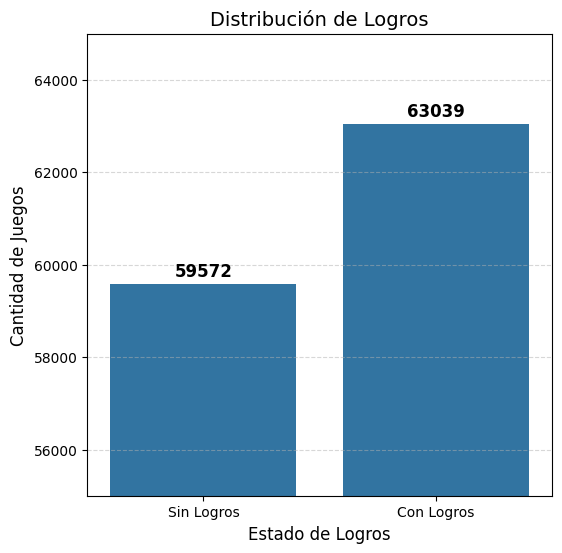

In [41]:
# Crear la etiqueta para el gráfico
df_copia['Tiene_Logros'] = df_copia['Achievements'].apply(lambda x: 'Con Logros' if x > 0 else 'Sin Logros')

# Configurar el gráfico
plt.figure(figsize=(6, 6))
ax = sns.countplot(data=df_copia, x='Tiene_Logros')

ax.bar_label(ax.containers[0], padding=3, fontsize=12, fontweight='bold')

# LIMITAR EJE Y (Zoom de 50k a 70k)
plt.ylim(55000, 65000)

# Títulos y etiquetas
plt.title('Distribución de Logros', fontsize=14)
plt.xlabel('Estado de Logros', fontsize=12)
plt.ylabel('Cantidad de Juegos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

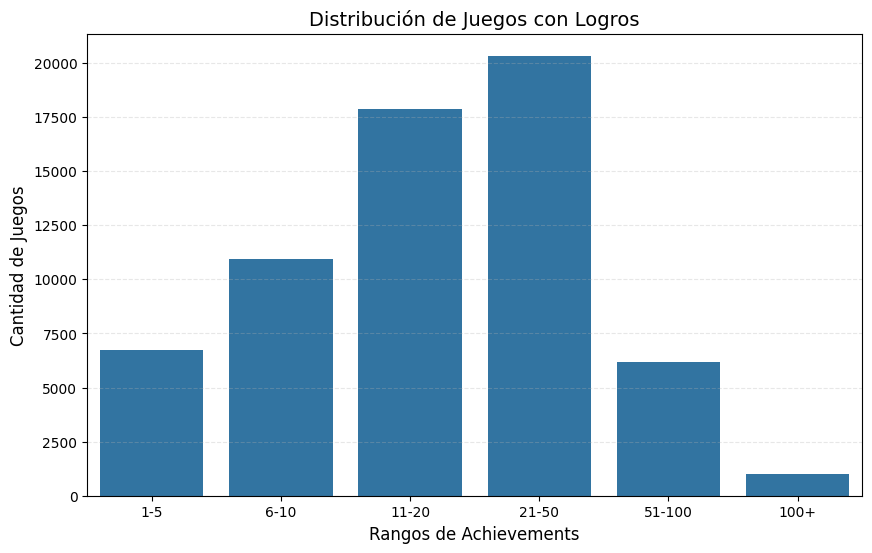

In [38]:
# Definimos los cortes y etiquetas (empezando desde 0 para que el primer rango sea 1-5)
bins = [0, 5, 10, 20, 50, 100, float('inf')]
labels = ['1-5', '6-10', '11-20', '21-50', '51-100', '100+']

# Creamos la columna solo para los que tienen más de 0
df_copia['Rango_Logros'] = pd.cut(df_copia[df_copia['Achievements'] > 0]['Achievements'], bins=bins, labels=labels)

# Graficamos filtrando los nulos (que son los que tenían 0 logros)
plt.figure(figsize=(10, 6))
sns.countplot(data=df_copia.dropna(subset=['Rango_Logros']), x='Rango_Logros')

plt.title('Distribución de Juegos con Logros', fontsize=14)
plt.xlabel('Rangos de Achievements', fontsize=12)
plt.ylabel('Cantidad de Juegos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

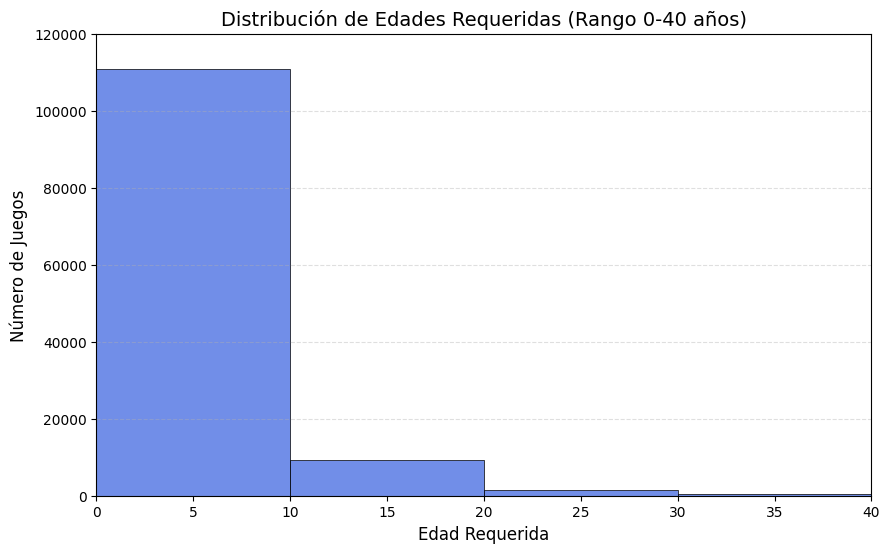

In [39]:
plt.figure(figsize=(10, 6))

# Filtramos visualmente con set(xlim, ylim) para no perder datos del dataframe
ax = sns.histplot(data=df_copia, x='Required age', bins=100, color='royalblue', kde=False)

# AJUSTE DE ZOOM
# Limitamos x de 0 a 100 años (que es el rango lógico de clasificación)
plt.xlim(0, 40)

# Ajustamos y al total de tus juegos (150k) o un poco más para que respire
plt.ylim(0, 120000)

plt.title('Distribución de Edades Requeridas (Rango 0-40 años)', fontsize=14)
plt.xlabel('Edad Requerida', fontsize=12)
plt.ylabel('Número de Juegos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

C:\Users\Juma0004\AppData\Local\Temp\ipykernel_6700\3853093731.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_positivos, x='Positive', y='Name', palette='Blues_r')


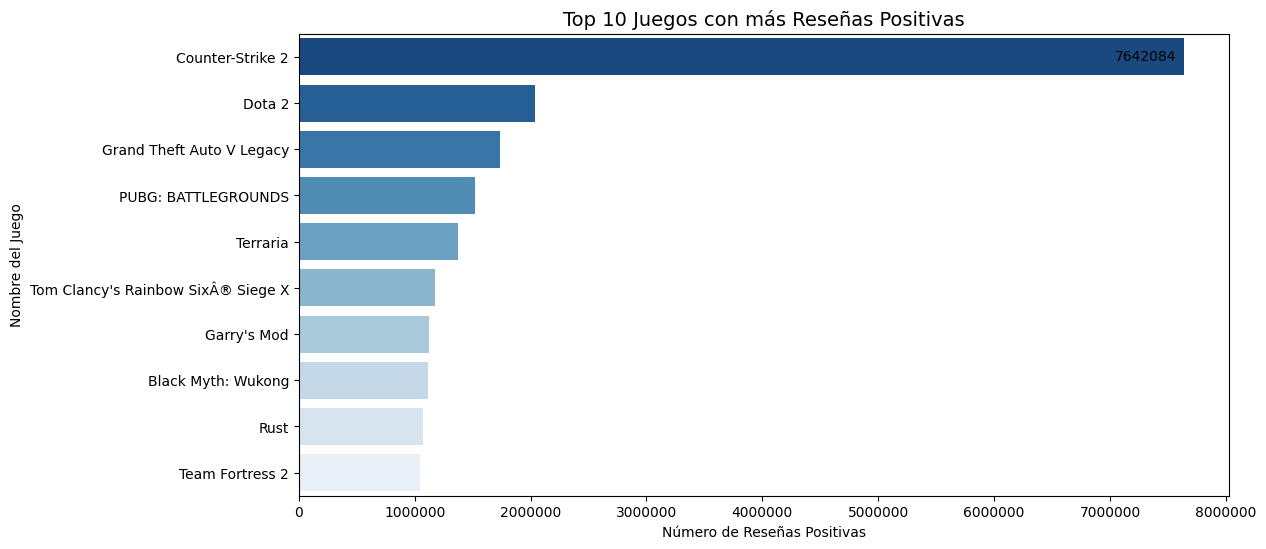

In [64]:
# Obtenemos los 10 juegos con más votos positivos
top_positivos = df_copia.nlargest(10, 'Positive')

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_positivos, x='Positive', y='Name', palette='Blues_r')

# 1. Poner los números completos sobre las barras (sin notación científica)
ax.bar_label(ax.containers[0], fmt='%d', padding=-50, fontsize=10)

# 2. Desactivar la notación científica en el eje X
plt.ticklabel_format(style='plain', axis='x')

plt.title('Top 10 Juegos con más Reseñas Positivas', fontsize=14)
plt.xlabel('Número de Reseñas Positivas')
plt.ylabel('Nombre del Juego')

plt.show()

C:\Users\Juma0004\AppData\Local\Temp\ipykernel_6700\3611511866.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_positivos, x='Negative', y='Name', palette='Blues_r')
C:\Users\Juma0004\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 132 (\x84) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


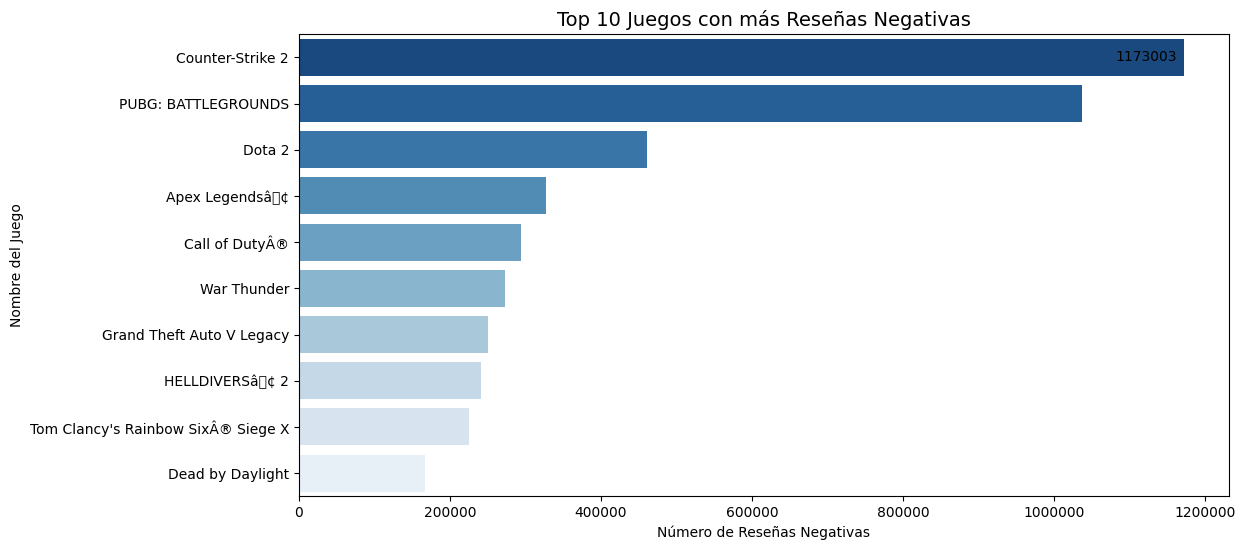

In [65]:
# Obtenemos los 10 juegos con más votos positivos
top_positivos = df_copia.nlargest(10, 'Negative')

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_positivos, x='Negative', y='Name', palette='Blues_r')

# 1. Poner los números completos sobre las barras (sin notación científica)
ax.bar_label(ax.containers[0], fmt='%d', padding=-50, fontsize=10)

# 2. Desactivar la notación científica en el eje X
plt.ticklabel_format(style='plain', axis='x')

plt.title('Top 10 Juegos con más Reseñas Negativas', fontsize=14)
plt.xlabel('Número de Reseñas Negativas')
plt.ylabel('Nombre del Juego')

plt.show()

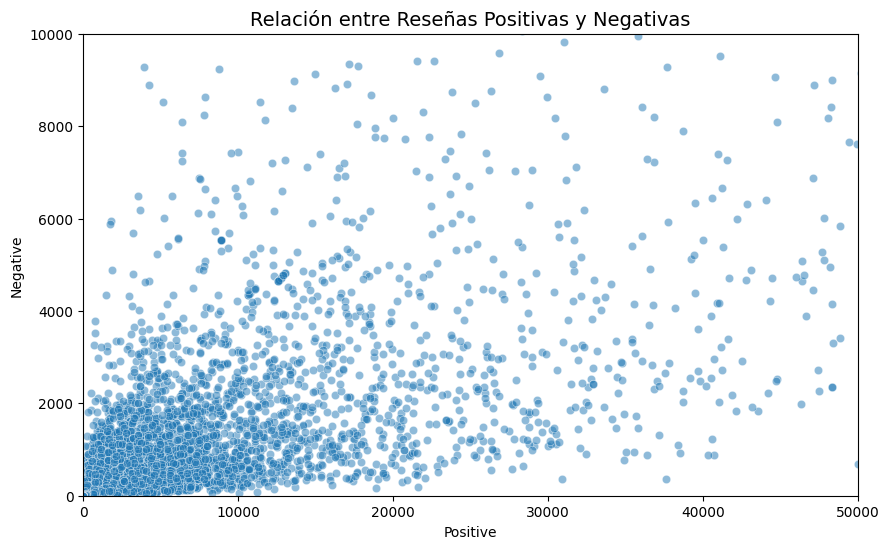

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copia, x='Positive', y='Negative', alpha=0.5)

# Limitar ejes para ignorar outliers extremos y ver el grueso de los datos
plt.xlim(0, 50000)
plt.ylim(0, 10000)

plt.title('Relación entre Reseñas Positivas y Negativas', fontsize=14)
plt.show()

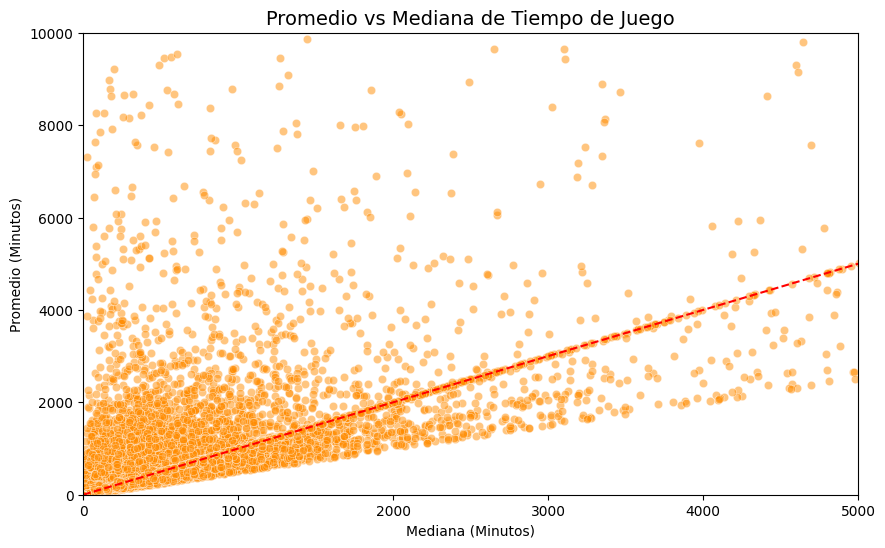

In [67]:
plt.figure(figsize=(10, 6))

# Scatter plot para comparar ambas métricas
sns.scatterplot(data=df_copia, x='Median playtime', y='Average playtime', alpha=0.5, color='darkorange')

# Dibujamos una línea de referencia (donde Promedio = Mediana)
plt.plot([0, 5000], [0, 5000], color='red', linestyle='--')

# Zoom para no perdernos en los valores extremos
plt.xlim(0, 5000)
plt.ylim(0, 10000)

plt.title('Promedio vs Mediana de Tiempo de Juego', fontsize=14)
plt.xlabel('Mediana (Minutos)')
plt.ylabel('Promedio (Minutos)')
plt.show()

C:\Users\Juma0004\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 132 (\x84) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


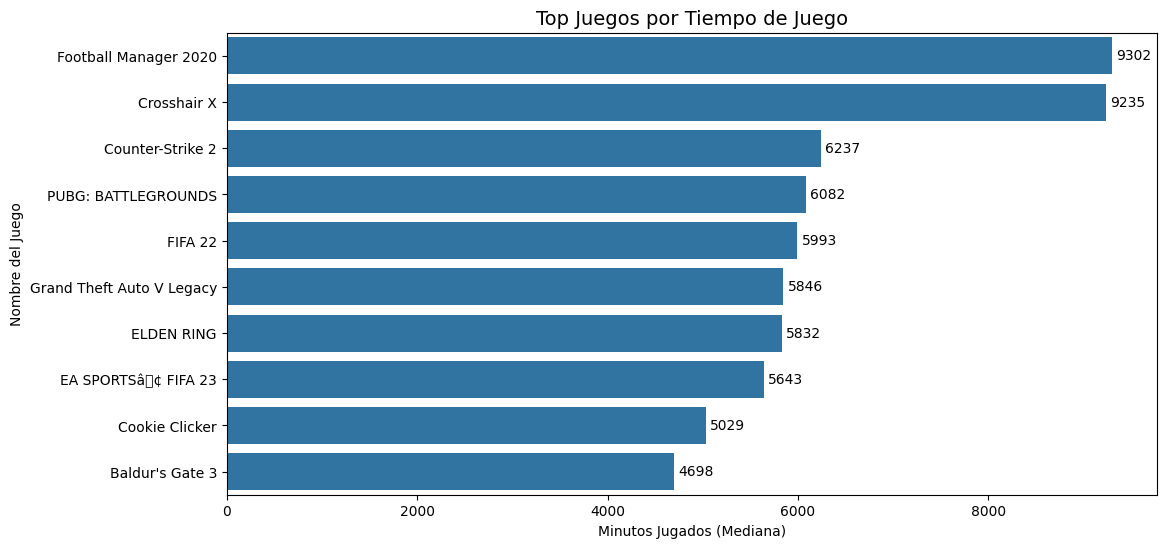

In [74]:
# Filtramos juegos con una base sólida de jugadores
populares = df_copia[df_copia['Positive'] > 10000]

# Ordenamos por Mediana de tiempo y seleccionamos del puesto 6 al 15
top_diversos_tiempo = populares.sort_values('Median playtime', ascending=False).iloc[5:15]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_diversos_tiempo, x='Median playtime', y='Name')

# Añadir etiquetas con los valores exactos
ax.bar_label(ax.containers[0], fmt='%d', padding=3)

plt.title('Top Juegos por Tiempo de Juego', fontsize=14)
plt.xlabel('Minutos Jugados (Mediana)')
plt.ylabel('Nombre del Juego')

plt.show()

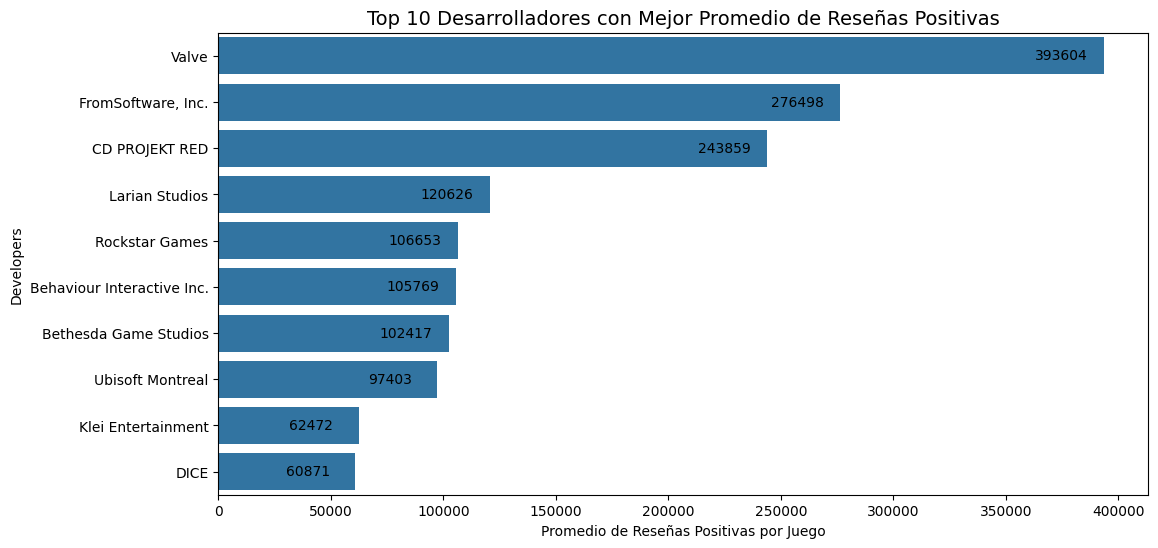

In [79]:
# Agrupamos por desarrollador y calculamos la media de positivos y el conteo de juegos
dev_stats = df_copia.groupby('Developers').agg({'Positive': 'mean', 'Name': 'count'})

# Filtramos: solo desarrolladores con más de 5 juegos para evitar "one-hit wonders"
top_calidad_dev = dev_stats[dev_stats['Name'] > 5].nlargest(10, 'Positive').reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_calidad_dev, x='Positive', y='Developers')
ax.bar_label(ax.containers[0], fmt='%d', padding=-50)

plt.title('Top 10 Desarrolladores con Mejor Promedio de Reseñas Positivas', fontsize=14)
plt.xlabel('Promedio de Reseñas Positivas por Juego')
plt.show()

C:\Users\Juma0004\AppData\Local\Temp\ipykernel_6700\921773442.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gigantes, x='Total_Reviews', y='Developers', palette='Blues_r')


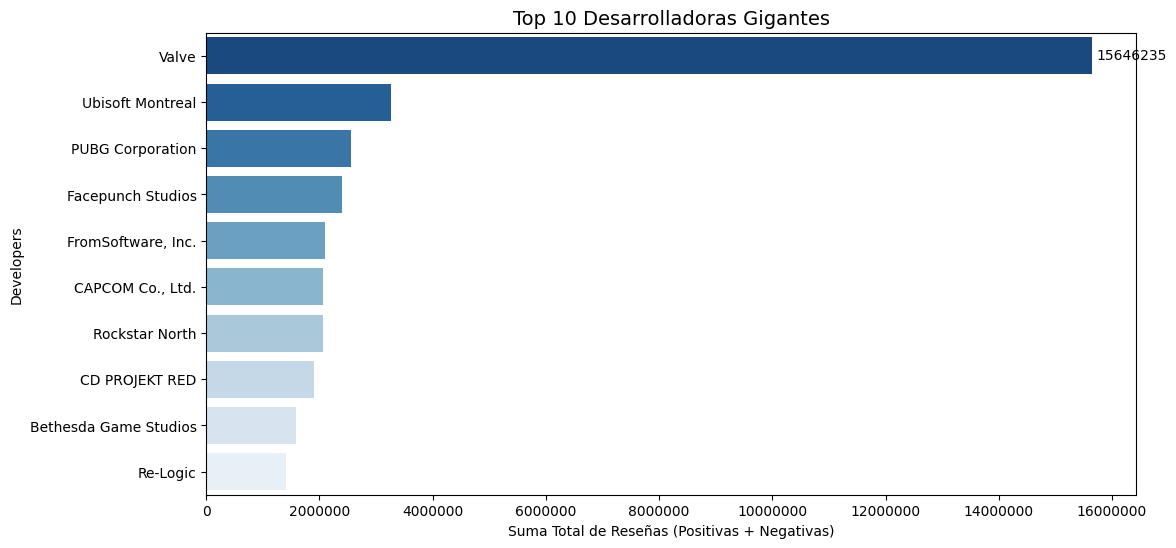

In [85]:
# Sumamos todos los votos para medir el tamaño del desarrollador
df_copia['Total_Reviews'] = df_copia['Positive'] + df_copia['Negative']

# Agrupamos por Developer y sumamos sus reseñas totales
gigantes = df_copia.groupby('Developers')['Total_Reviews'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=gigantes, x='Total_Reviews', y='Developers', palette='Blues_r')

# Formateamos los números para que no salga notación científica
ax.bar_label(ax.containers[0], fmt='%d', padding=3)
plt.ticklabel_format(style='plain', axis='x')

plt.title('Top 10 Desarrolladoras Gigantes', fontsize=14)
plt.xlabel('Suma Total de Reseñas (Positivas + Negativas)')
plt.show()

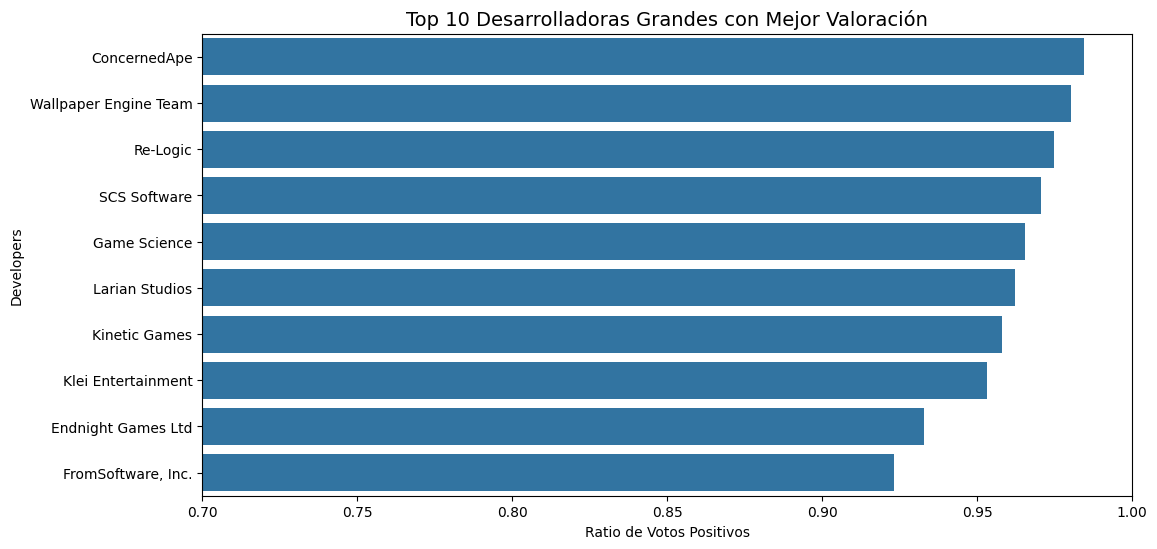

In [89]:
# Agrupamos datos
stats_dev = df_copia.groupby('Developers').agg({
    'Positive': 'sum',
    'Negative': 'sum',
    'Total_Reviews': 'sum'
})

# Calculamos el Ratio
stats_dev['Ratio'] = stats_dev['Positive'] / stats_dev['Total_Reviews']

# Filtramos: Solo estudios con más de 500,000 reseñas totales
grandes_calidad = stats_dev[stats_dev['Total_Reviews'] > 500000].nlargest(10, 'Ratio').reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=grandes_calidad, x='Ratio', y='Developers')

plt.xlim(0.7, 1.0) # Zoom para ver la competencia en la cima
plt.title('Top 10 Desarrolladoras Grandes con Mejor Valoración', fontsize=14)
plt.xlabel('Ratio de Votos Positivos')
plt.show()